In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import torchvision
# from sklearn.datasets import load_boston
from torch import nn
from tqdm.notebook import tqdm
from IPython.display import clear_output

%matplotlib inline

In [2]:
print(torch.backends.mps.is_available())        # True — значит можно использовать
print(torch.backends.mps.is_built())            # True — значит PyTorch собран с поддержкой

True
True


In [27]:
# device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [3]:
mnist_train = torchvision.datasets.MNIST(
    "./mnist/", 
    train=True, 
    download=True, 
    transform=torchvision.transforms.ToTensor()
) 
mnist_val = torchvision.datasets.MNIST(
    "./mnist/",
    train=False, 
    download=True,
    transform=torchvision.transforms.ToTensor()
)

train_dataloader = torch.utils.data.DataLoader(
    mnist_train, 
    batch_size=4, 
    shuffle=True, 
    num_workers=1
) 

val_dataloader = torch.utils.data.DataLoader(
    mnist_val, 
    batch_size=4, 
    shuffle=True, 
    num_workers=1
)

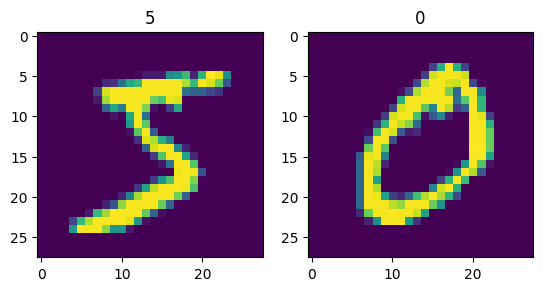

In [4]:
for i in [0, 1]:
    plt.subplot(1, 2, i + 1)
    plt.imshow(mnist_train[i][0].squeeze(0).numpy().reshape([28, 28]))
    plt.title(str(mnist_train[i][1]))
plt.show()

In [5]:
model = nn.Sequential(
    nn.Flatten(),             # превращаем картинку 28х28 в вектор размером 784
    nn.Linear(28 * 28, 128),  # линейный слой, преобразующий вектор размера 784 в вектор размера 128
    nn.ReLU(),                # нелинейность
    nn.Linear(128, 10),       # линейный слой, преобразующий вектор размера 128 в вектор размера 10
    # nn.Softmax(dim=-1)        # софтмакс для получения вероятностного распределения над метками класса
)

optimizer = torch.optim.SGD(model.parameters(), lr=0.05) 
# optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

In [40]:
for x_train, y_train in tqdm(train_dataloader):
    break
x_train.shape

  0%|          | 0/15000 [00:00<?, ?it/s]

torch.Size([4, 1, 28, 28])

In [42]:
for epoch in range(15):
    for x_train, y_train in tqdm(train_dataloader):  
        y_pred = model(x_train)                       
        loss = F.cross_entropy(y_pred, y_train)      
        loss.backward()                               
        optimizer.step()                        
        optimizer.zero_grad()         
    
    if epoch % 2 == 0:
        val_loss = []                         
        val_accuracy = []
        with torch.no_grad():                  
            for x_val, y_val in tqdm(val_dataloader): 
                y_pred = model(x_val)                
                loss = F.cross_entropy(y_pred, y_val)  
                val_loss.append(loss.numpy())      
                val_accuracy.extend((torch.argmax(y_pred, dim=-1) == y_val).numpy().tolist())
          
        print(f"Epoch: {epoch}, loss: {np.mean(val_loss)}, accuracy: {np.mean(val_accuracy)}")

  0%|          | 0/15000 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

Epoch: 0, loss: 0.0923798680305481, accuracy: 0.973


  0%|          | 0/15000 [00:00<?, ?it/s]

  0%|          | 0/15000 [00:00<?, ?it/s]

...

Epoch: 12, loss: 0.08054862916469574, accuracy: 0.9823


  0%|          | 0/15000 [00:00<?, ?it/s]

  0%|          | 0/15000 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

Epoch: 14, loss: 0.0822008028626442, accuracy: 0.9826


In [6]:
torch.save(model.state_dict(), "model_weights.pth")

model.load_state_dict(torch.load("model_weights.pth"))
model.eval()

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)

# adversarial attacks

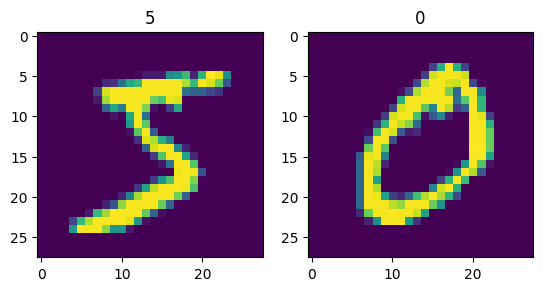

In [8]:
for i in [0, 1]:
    plt.subplot(1, 2, i + 1)
    plt.imshow(mnist_train[i][0].squeeze(0).numpy())
    plt.title(str(mnist_train[i][1]))
plt.show()

In [9]:
mnist_train[0][0].unsqueeze(0).shape

torch.Size([1, 1, 28, 28])

In [10]:
print("model predict:", model(mnist_train[0][0].unsqueeze(0)).argmax(dim=1))
print("target:", mnist_train[0][-1])

model predict: tensor([9])
target: 5


# cross_entropy

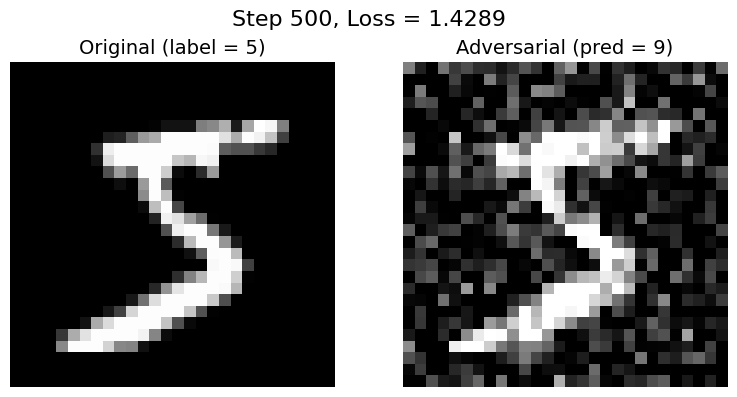

In [34]:
model.eval() 

x, original_label = mnist_train[0][0].unsqueeze(0), mnist_train[0][1]
x_adv = x.clone().detach().requires_grad_(True)
target_label = torch.tensor([9])

optimizer = torch.optim.SGD([x_adv], lr=0.1)  

for i in range(500):
    optimizer.zero_grad()
    output = model(x_adv)
    loss = F.cross_entropy(output, target_label)
    loss.backward()
    optimizer.step()
    
    # Ограничение значений пикселей
    with torch.no_grad():
        x_adv.data = torch.clamp(x_adv.data, min=0, max=1)
    
    pred = output.argmax(dim=1).item()
    

    if (i + 1) % 5 == 0:
        clear_output(wait=True)
        plt.figure(figsize=(8, 4))
        
        plt.subplot(1, 2, 1)
        plt.title(f"Original (label = {original_label})", fontsize=14)
        plt.imshow(x.squeeze().detach().numpy(), cmap="gray")
        plt.axis("off")
        
        plt.subplot(1, 2, 2)
        plt.title(f"Adversarial (pred = {pred})", fontsize=14)
        plt.imshow(x_adv.squeeze().detach().numpy(), cmap="gray")
        plt.axis("off")
        
        plt.suptitle(f"Step {i+1}, Loss = {loss.item():.4f}", fontsize=16)
        plt.tight_layout()
        plt.show()

Атака срабатывает уже на 5 шаге. При большом количестве шагов похоже больше на шум.
* Попробуем сменить лосс.

# MSE 

In [32]:
# Возьмём целевое значение
mnist_train[4][1]

9

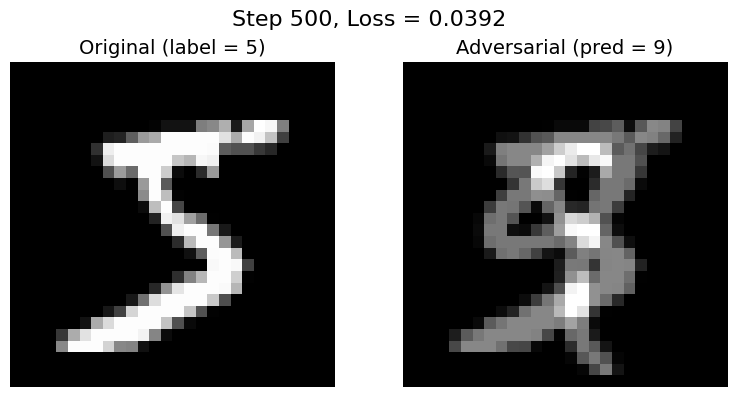

In [46]:
model.eval() 


x, original_label = mnist_train[0][0].unsqueeze(0), mnist_train[0][1]
x_adv = x.clone().detach().requires_grad_(True)
# target_label = torch.tensor([9])

optimizer = torch.optim.SGD([x_adv], lr=0.5)  
target_x = mnist_train[4][0].unsqueeze(0)

for i in range(500):
    optimizer.zero_grad()
    output = model(x_adv)
    # loss = F.cross_entropy(output, target_label)
    loss = F.mse_loss(x_adv, target_x)
    loss.backward()
    optimizer.step()
    
    # Ограничение значений пикселей
    with torch.no_grad():
        x_adv.data = torch.clamp(x_adv.data, min=0, max=1)
    
    pred = output.argmax(dim=1).item()
    

    if (i + 1) % 5 == 0:
        clear_output(wait=True)
        plt.figure(figsize=(8, 4))
        
        plt.subplot(1, 2, 1)
        plt.title(f"Original (label = {original_label})", fontsize=14)
        plt.imshow(x.squeeze().detach().numpy(), cmap="gray")
        plt.axis("off")
        
        plt.subplot(1, 2, 2)
        plt.title(f"Adversarial (pred = {pred})", fontsize=14)
        plt.imshow(x_adv.squeeze().detach().numpy(), cmap="gray")
        plt.axis("off")
        
        plt.suptitle(f"Step {i+1}, Loss = {loss.item():.4f}", fontsize=16)
        plt.tight_layout()
        plt.show()

Модель весьма бысто создаёт адверсариал атаку. Замена происходит. Попробуем скомбинировать два лосса

# MSE + cross_entropy

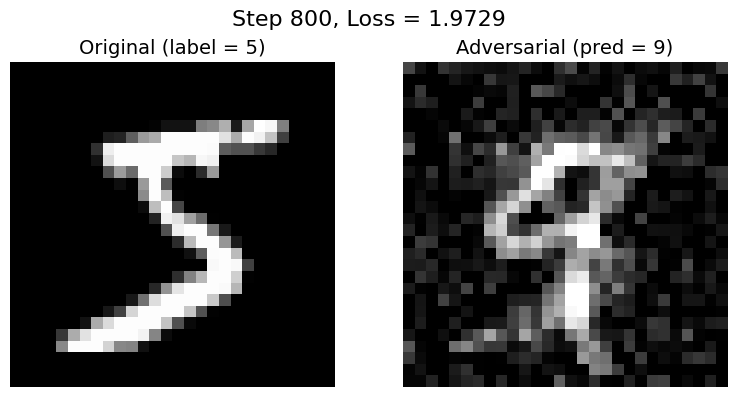

In [64]:
model.eval() 

x, original_label = mnist_train[0][0].unsqueeze(0), mnist_train[0][1]
x_adv = x.clone().detach().requires_grad_(True)
target_label = torch.tensor([9])

optimizer = torch.optim.SGD([x_adv], lr=0.05)  
target_x = mnist_train[4][0].unsqueeze(0)

for i in range(800):
    optimizer.zero_grad()
    output = model(x_adv)

    classification_loss = F.cross_entropy(output, target_label)
    similarity_loss = F.mse_loss(x_adv, target_x)
    loss = classification_loss + 10 * similarity_loss
    
    loss.backward()
    optimizer.step()
    
    # Ограничение значений пикселей
    with torch.no_grad():
        x_adv.data = torch.clamp(x_adv.data, min=0, max=1)
    
    pred = output.argmax(dim=1).item()
    

    if (i + 1) % 5 == 0:
        clear_output(wait=True)
        plt.figure(figsize=(8, 4))
        
        plt.subplot(1, 2, 1)
        plt.title(f"Original (label = {original_label})", fontsize=14)
        plt.imshow(x.squeeze().detach().numpy(), cmap="gray")
        plt.axis("off")
        
        plt.subplot(1, 2, 2)
        plt.title(f"Adversarial (pred = {pred})", fontsize=14)
        plt.imshow(x_adv.squeeze().detach().numpy(), cmap="gray")
        plt.axis("off")
        
        plt.suptitle(f"Step {i+1}, Loss = {loss.item():.4f}", fontsize=16)
        plt.tight_layout()
        plt.show()

# Projected Gradient Descent

In [67]:
epsilon = 0.3
alpha = 0.01  
num_iter = 100

x_adv = x.clone().detach().requires_grad_(True)

for i in range(num_iter):
    output = model(x_adv)
    loss = F.cross_entropy(output, target_label)
    loss.backward()
    
    with torch.no_grad():
        x_adv.data = x_adv - alpha * x_adv.grad.sign()
        perturbation = torch.clamp(x_adv - x, min=-epsilon, max=epsilon)
        x_adv.data = torch.clamp(x + perturbation, min=0, max=1)
    
    x_adv.requires_grad_(True)
    
    pred = output.argmax(dim=1).item()
    
    if (i + 1) % 5 == 0:
        print(f"Step {i+1}, Loss = {loss.item():.4f}, Pred = {pred}")
        if pred == target_label.item():
            print("Атака успешна!")
            break

Step 5, Loss = 2.0410, Pred = 9
Атака успешна!
